In [32]:
import sympy
from sympy import symbols, solve
from sympy.physics.mechanics import dynamicsymbols, ReferenceFrame
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve, least_squares
from matplotlib.animation import FuncAnimation
from IPython.display import HTML


# Correcciones realizadas

El notebook fallaba principalmente por dos problemas geométricos:

1. El cierre vectorial estaba mal definido:

   `eqLoop = r1 + r2 + r3 + r4`

   Debe ser:

   `eqLoop = r1 + r2 + r3 - r4`

2. `PC_prime` debía ser `r4` y no `-r4`.

Con la geometría original modificada a un ground offset `(L4x, L4y)`, el signo es crítico.


In [44]:

# Define symbols
t, g = symbols('t g')

# Longitudes y parámetros
L1,L2,L3,L4x,L4y,m1,m2,m3,I1,I2,I3 = symbols(
    'L1 L2 L3 L4x L4y m1 m2 m3 I1 I2 I3'
)

theta1,theta2,theta3 = dynamicsymbols('theta1 theta2 theta3')

params = {
    L1: 0.20,
    L2: 0.24,
    L3: 0.08,
    L4x: 0.19,
    L4y: 0.07,
    g: 9.81,
    m1: 0.1,
    m2: 0.1,
    m3: 0.1,
    I1: 1e-6,
    I2: 1e-6,
    I3: 1e-6
}

# Frames
N = ReferenceFrame('N')
O = N.orientnew('O', 'Axis', [theta1, N.z])
A = N.orientnew('A', 'Axis', [theta2, N.z])
B = N.orientnew('B', 'Axis', [theta3, N.z])

# Fuerzas
F01x, F01y, F12x, F12y, F23x, F23y, F03x, F03y, Min = symbols(
    'F01x F01y F12x F12y F23x F23y F03x F03y Min'
)

# Vectores de eslabones
r1 = L1 * O.x
r2 = L2 * A.x
r3 = L3 * B.x

# Ground offset
r4 = L4x * N.x + L4y * N.y

# Centros de masa
r1cm = r1/2
r2cm = r1 + r2/2
r3cm = r1 + r2 + r3/2

# Aceleraciones
a1cm = r1cm.diff(t, N).diff(t, N)
a2cm = r2cm.diff(t, N).diff(t, N)
a3cm = r3cm.diff(t, N).diff(t, N)

alpha1 = theta1.diff(t, t)
alpha2 = theta2.diff(t, t)
alpha3 = theta3.diff(t, t)

# Fuerzas vectoriales
F01 = F01x * N.x + F01y * N.y
F12 = F12x * N.x + F12y * N.y
F23 = F23x * N.x + F23y * N.y
F03 = F03x * N.x + F03y * N.y

# Newton-Euler
eqF1 = F01 - F12 - m1*g*N.y - m1*a1cm
eqM1 = Min*N.z + (-r1/2).cross(F01) + (r1/2).cross(-F12) - I1*alpha1*N.z

eqF2 = F12 - F23 - m2*g*N.y - m2*a2cm
eqM2 = (-r2/2).cross(F12) + (r2/2).cross(-F23) - I2*alpha2*N.z

eqF3 = F23 + F03 - m3*g*N.y - m3*a3cm
eqM3 = (-r3/2).cross(F23) + (r3/2).cross(F03) - I3*alpha3*N.z

eqKinetics = [
    eqF1.dot(N.x), eqF1.dot(N.y), eqM1.dot(N.z),
    eqF2.dot(N.x), eqF2.dot(N.y), eqM2.dot(N.z),
    eqF3.dot(N.x), eqF3.dot(N.y), eqM3.dot(N.z)
]

# ==========================================================
# CORRECCIÓN IMPORTANTE:
# El loop vectorial debe cerrar restando el ground vector.
# Antes estaba:
# eqLoop = r1 + r2 + r3 + r4
# Eso rompe la geometría.
# ==========================================================

eqLoop = r1 + r2 + r3 - r4

PA = r1
PB = r1 + r2
PC = r1 + r2 + r3
PC_prime = r4

eqKin = [
    eqLoop.subs(params).dot(N.x),
    eqLoop.subs(params).dot(N.y)
]

eqKin_fun = sympy.lambdify([theta1, theta2, theta3], eqKin)

points_fun = [
    sympy.lambdify(
        [theta1, theta2, theta3],
        [point.subs(params).dot(N.x), point.subs(params).dot(N.y)]
    )
    for point in [PA, PB, PC, PC_prime]
]

# Resolver cinemática
myfun = lambda x: eqKin_fun(np.deg2rad(60), x[0], x[1])

# Mejor guess inicial
initial_guess = [np.deg2rad(60), np.deg2rad(130)]

sln, out, ier, conv_str = fsolve(
    myfun,
    initial_guess,
    full_output=True
)

print("Estado convergencia:", ier)
print(conv_str)

print(f"theta2 = {np.rad2deg(sln[0]):.3f} deg")
print(f"theta3 = {np.rad2deg(sln[1]):.3f} deg")

print("Residual:", out["fvec"])


Estado convergencia: 5
The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
theta2 = -48.977 deg
theta3 = 490.918 deg
Residual: [ 0.01513003 -0.01740894]


In [34]:
eqLoop=r1+r2+r3+r4
Av,bv=sympy.linear_eq_to_matrix([eqLoop.diff(t,N).dot(N.x), eqLoop.diff(t,N).dot(N.y)], [theta2.diff(t), theta3.diff(t)])
Aa,ba=sympy.linear_eq_to_matrix([eqLoop.diff(t,N).diff(t,N).dot(N.x), eqLoop.diff(t,N).diff(t,N).dot(N.y)], [theta2.diff(t,2), theta3.diff(t,2)])

#Solve for velocities
bv_num=bv.subs(params).subs(theta1.diff(t),2*np.pi/3).subs(theta1,np.deg2rad(60))
Av_num=Av.subs(params).subs(theta2,sln[0]).subs(theta3,sln[1])
sln_V = np.linalg.inv(np.array(Av_num,np.float64))@np.array(bv_num,np.float64)

sln_V


array([[ 990.91897566],
       [3395.50560423]])

In [35]:
Af,bf=sympy.linear_eq_to_matrix(eqKinetics, [F01x, F01y, F12x, F12y, F23x, F23y, F03x, F03y, Min])
display(Af.subs(params))
display(bf.subs(params))

Af.subs(params).subs({theta1:np.deg2rad(60), theta2:sln[0], theta3:sln[1], theta1.diff(t):1, theta2.diff(t):0, theta3.diff(t):0, theta1.diff(t, t):0, theta2.diff(t, t):0, theta3.diff(t, t):0})

Matrix([
[                 1,                   0,                  -1,                    0,                    0,                     0,                     0,                    0, 0],
[                 0,                   1,                   0,                   -1,                    0,                     0,                     0,                    0, 0],
[0.1*sin(theta1(t)), -0.1*cos(theta1(t)),  0.1*sin(theta1(t)),  -0.1*cos(theta1(t)),                    0,                     0,                     0,                    0, 1],
[                 0,                   0,                   1,                    0,                   -1,                     0,                     0,                    0, 0],
[                 0,                   0,                   0,                    1,                    0,                    -1,                     0,                    0, 0],
[                 0,                   0, 0.12*sin(theta2(t)), -0.12*cos(theta2(t)),  0.12*sin(t

Matrix([
[                                                                                                                                                                                                                          -0.01*sin(theta1(t))*Derivative(theta1(t), (t, 2)) - 0.01*cos(theta1(t))*Derivative(theta1(t), t)**2],
[                                                                                                                                                                                                                  -0.01*sin(theta1(t))*Derivative(theta1(t), t)**2 + 0.01*cos(theta1(t))*Derivative(theta1(t), (t, 2)) + 0.981],
[                                                                                                                                                                                                                                                                                          1.0e-6*Derivative(theta1(t), (t, 2))],
[                        

Matrix([
[                 1,     0,                  -1,                   0,                   0,                   0,                   0,                   0, 0],
[                 0,     1,                   0,                  -1,                   0,                   0,                   0,                   0, 0],
[0.0866025403784439, -0.05,  0.0866025403784439,               -0.05,                   0,                   0,                   0,                   0, 1],
[                 0,     0,                   1,                   0,                  -1,                   0,                   0,                   0, 0],
[                 0,     0,                   0,                   1,                   0,                  -1,                   0,                   0, 0],
[                 0,     0, -0.0903898057011783, -0.0789283410778615, -0.0903898057011783, -0.0789283410778615,                   0,                   0, 0],
[                 0,     0,                

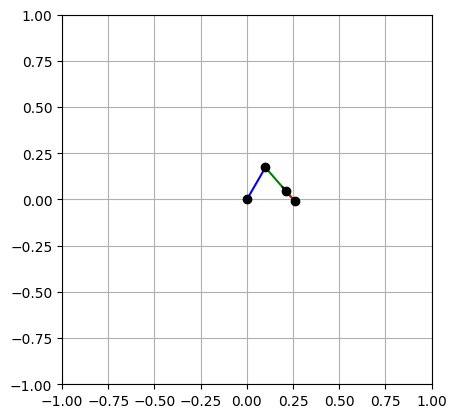

In [36]:
z0=[np.deg2rad(-15), np.deg2rad(80)]
def FK(theta1):
    global z0
    myfun=lambda x:eqKin_fun(theta1,x[0],x[1])
    sln,_,convergence,_=fsolve(myfun,z0,full_output=True)    
    if convergence:
        z0 = sln
    return sln

def plot4bar(ax, thetas):
    PO = np.array([0, 0])
    PA = points_fun[0](*thetas)
    PB = points_fun[1](*thetas)
    PC = points_fun[2](*thetas)
    PC_prime = points_fun[3](*thetas)
    ax.plot([PO[0], PA[0]], [PO[1], PA[1]], 'b-')
    ax.plot(PO[0], PO[1], 'ko')
    ax.plot([PA[0], PB[0]], [PA[1], PB[1]], 'g-')
    ax.plot(PA[0], PA[1], 'ko')
    ax.plot([PB[0], PC[0]], [PB[1], PC[1]], 'r-')
    ax.plot(PB[0], PB[1], 'ko')
    ax.plot([PC[0], PC_prime[0]], [PC[1], PC_prime[1]], 'k--')
    ax.plot(PC[0], PC[1], 'ko')
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.grid(True)

fig, ax = plt.subplots()
thetasList=np.array([[theta1,*FK(theta1)] for theta1 in np.linspace(np.deg2rad(60), np.deg2rad(60+360), 100)])

def update_fun(i):
    ax.cla()                  
    ax.set_aspect('equal')    
    plot4bar(ax, thetasList[i, :])

anim = FuncAnimation(fig, update_fun, len(thetasList), repeat=False)
HTML(anim.to_jshtml())

In [37]:
[PA,PB,PC,PC_prime]

[L1*O.x, L1*O.x + L2*A.x, L1*O.x + L2*A.x + L3*B.x, L4x*N.x + L4y*N.y]

In [38]:
thetasList #aquí ya están todos los valores de los ángulos theta1, theta2 y theta3 para cada posición del mecanismo, con theta1 iniciando en 60 grados y terminando en 420 grados, con un paso de 100 posiciones en total.

array([[ 1.04719755e+00, -8.53581721e-01,  2.28821510e+00],
       [ 1.11066407e+00, -8.23099402e-01,  2.32066987e+00],
       [ 1.17413059e+00, -7.93179658e-01,  2.34817851e+00],
       [ 1.23759711e+00, -8.49771449e-01,  2.07553896e+00],
       [ 1.30106362e+00, -9.30408691e-01,  1.66660396e+00],
       [ 1.36453014e+00, -9.49410037e-01,  1.43726303e+00],
       [ 1.42799666e+00, -9.46157687e-01,  1.26334656e+00],
       [ 1.49146318e+00, -9.29601978e-01,  1.11848345e+00],
       [ 1.55492970e+00, -9.03678638e-01,  9.91285975e-01],
       [ 1.61839622e+00, -8.70506279e-01,  8.75351296e-01],
       [ 1.68186273e+00, -8.31308810e-01,  7.66388792e-01],
       [ 1.74532925e+00, -7.86760034e-01,  6.61028574e-01],
       [ 1.80879577e+00, -7.37104500e-01,  5.56124891e-01],
       [ 1.87226229e+00, -6.82133763e-01,  4.48099334e-01],
       [ 1.93572881e+00, -6.20961085e-01,  3.31865805e-01],
       [ 1.99919533e+00, -5.51234015e-01,  1.98019099e-01],
       [ 2.06266184e+00, -4.65449609e-01

In [39]:
eqLoop=r1+r2+r3+r4
Av,bv=sympy.linear_eq_to_matrix([eqLoop.diff(t,N).dot(N.x), eqLoop.diff(t,N).dot(N.y)], [theta2.diff(t), theta3.diff(t)])
Aa,ba=sympy.linear_eq_to_matrix([eqLoop.diff(t,N).diff(t,N).dot(N.x), eqLoop.diff(t,N).diff(t,N).dot(N.y)], [theta2.diff(t,2), theta3.diff(t,2)])

lista_total = []
#Derivando el loop de vectores 1 y dos veces se calcula para cada posición la velocidad angular y aceleración angular de los brazos del mecanismo

for thetas in thetasList:
    bv_num=bv.subs(params).subs(theta1.diff(t),2*np.pi/3).subs(theta1,thetas[0]) #reemplazamos la velocidad de theta1 por 2pi/3 (20 rpm constante))
    Av_num=Av.subs(params).subs(theta2,thetas[1]).subs(theta3,thetas[2])
    sln_V = np.linalg.inv(np.array(Av_num,np.float64))@np.array(bv_num,np.float64)
    ba_num = ba.subs(params).subs(theta1.diff(t, t),0).subs(theta1.diff(t),2*np.pi/3).subs(theta2.diff(t),sln_V[0][0]).subs(theta3.diff(t),sln_V[1][0]).subs(theta1,thetas[0]).subs(theta2,thetas[1]).subs(theta3,thetas[2])
    Aa_num=Aa.subs(params).subs(theta2,thetas[1]).subs(theta3,thetas[2])
    sln_A = np.linalg.inv(np.array(Aa_num,np.float64))@np.array(ba_num,np.float64)
    lista_total.append([thetas[0],thetas[1],thetas[2],2*np.pi/3, sln_V[0][0], sln_V[1][0], 0, sln_A[0][0], sln_A[1][0]]) #tras cada iteración del ángulo theta1, se guarda en una lista el valor de los ángulos, velocidades y aceleraciones angulares

lista_total=np.array(lista_total)

#separamos estas son las columnas de la matriz lista_total, cada una corresponde a un ángulo, velocidad o aceleración angular de los brazos del mecanismo
thetas1=lista_total[:,0]
thetas2=lista_total[:,1]
thetas3=lista_total[:,2]
omegas1=lista_total[:,3]
omegas2=lista_total[:,4]
omegas3=lista_total[:,5]
alphas1=lista_total[:,6]
alphas2=lista_total[:,7]
alphas3=lista_total[:,8]



In [40]:
Af,bf=sympy.linear_eq_to_matrix(eqKinetics, [F01x, F01y, F12x, F12y, F23x, F23y, F03x, F03y, Min])
display(Af.subs(params))
display(bf.subs(params))
#pasamos las ecuaciones de cinética a matrices y vector para resolver numéricamente el sistema de ecuaciones

MinList = [] #llenamos esta lista calculando el valor del Min para cada una de las posiciones del mecanismo, usando las ecuaciones de Newton-Euler y los valores de ángulos, velocidades y aceleraciones angulares calculados previamente
for i in range(len(lista_total)):
    Afnum = Af.subs(params).subs({theta1.diff(t,t):alphas1[i], theta2.diff(t,t):alphas2[i], theta3.diff(t,t):alphas3[i], theta1.diff(t):omegas1[i], theta2.diff(t):omegas2[i], theta3.diff(t):omegas3[i], theta1:thetas1[i], theta2:thetas2[i], theta3:thetas3[i]})
    bfnum = bf.subs(params).subs({theta1.diff(t,t):alphas1[i], theta2.diff(t,t):alphas2[i], theta3.diff(t,t):alphas3[i], theta1.diff(t):omegas1[i], theta2.diff(t):omegas2[i], theta3.diff(t):omegas3[i], theta1:thetas1[i], theta2:thetas2[i], theta3:thetas3[i]})
    sln_forces = np.linalg.inv(np.array(Afnum,np.float64))@np.array(bfnum,np.float64)
    MinList.append(sln_forces[8][0])


Matrix([
[                 1,                   0,                  -1,                    0,                    0,                     0,                     0,                    0, 0],
[                 0,                   1,                   0,                   -1,                    0,                     0,                     0,                    0, 0],
[0.1*sin(theta1(t)), -0.1*cos(theta1(t)),  0.1*sin(theta1(t)),  -0.1*cos(theta1(t)),                    0,                     0,                     0,                    0, 1],
[                 0,                   0,                   1,                    0,                   -1,                     0,                     0,                    0, 0],
[                 0,                   0,                   0,                    1,                    0,                    -1,                     0,                    0, 0],
[                 0,                   0, 0.12*sin(theta2(t)), -0.12*cos(theta2(t)),  0.12*sin(t

Matrix([
[                                                                                                                                                                                                                          -0.01*sin(theta1(t))*Derivative(theta1(t), (t, 2)) - 0.01*cos(theta1(t))*Derivative(theta1(t), t)**2],
[                                                                                                                                                                                                                  -0.01*sin(theta1(t))*Derivative(theta1(t), t)**2 + 0.01*cos(theta1(t))*Derivative(theta1(t), (t, 2)) + 0.981],
[                                                                                                                                                                                                                                                                                          1.0e-6*Derivative(theta1(t), (t, 2))],
[                        

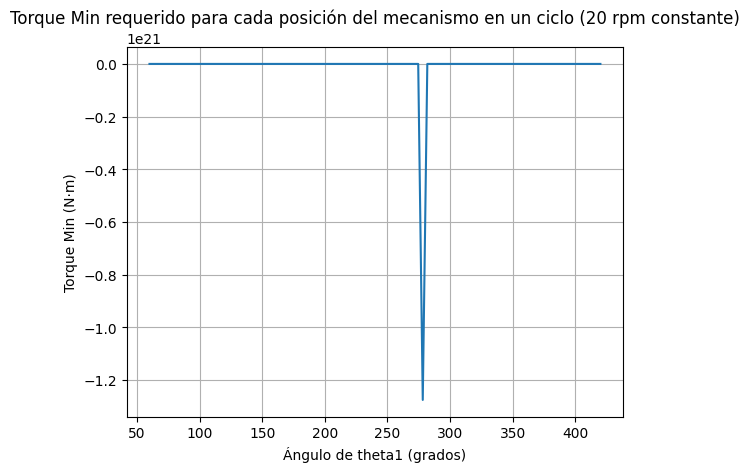

In [41]:
#Hacemos la gráfica solicitada, el momento Min requerido para cada posición del mecanismo en un ciclo (20 rpm constante), con theta1 iniciando en 60 grados y terminando en 420 grados
plt.figure()
plt.plot(np.rad2deg(thetas1), MinList)
plt.title('Torque Min requerido para cada posición del mecanismo en un ciclo (20 rpm constante)')
plt.xlabel('Ángulo de theta1 (grados)')
plt.ylabel('Torque Min (N·m)')
plt.grid()
plt.show()